## Data loading 

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_percentage_error,mean_absolute_error
import yfinance as yf
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [34]:
df = yf.download("AAPL", start = "2015-01-01", end= "2026-04-09")
df.to_csv("AAPL.csv")

[*********************100%***********************]  1 of 1 completed


In [35]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.214903,24.682235,23.776363,24.671160,212818400
2015-01-05,23.532724,24.064287,23.346678,23.984553,257142000
2015-01-06,23.534931,23.794068,23.173911,23.596947,263188400
2015-01-07,23.864948,23.964616,23.632389,23.743131,160423600
2015-01-08,24.781895,24.839481,24.075359,24.192747,237458000


In [36]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-04-01,255.630005,256.179993,253.330002,254.080002,40059400
2026-04-02,255.919998,256.130005,250.649994,254.199997,31289400
2026-04-06,258.859985,262.160004,256.459991,256.510010,29329900
2026-04-07,253.500000,256.200012,245.699997,256.160004,62148000
2026-04-08,258.899994,259.750000,256.529999,258.450012,41032800


In [37]:
df.shape

(2832, 5)

In [38]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2832.000000,2832.000000,2832.000000,2832.000000,2.832000e+03
mean,109.806183,110.903418,108.612255,109.718279,1.099094e+08
std,76.967196,77.720095,76.154356,76.909880,6.797401e+07
min,20.584818,20.887870,20.386581,20.507345,1.791060e+07
25%,37.097626,37.428631,36.689746,37.080099,6.311622e+07
50%,107.174034,109.047812,105.552688,107.231084,9.310420e+07
75%,171.083996,172.144445,169.009016,170.646411,1.357272e+08
max,285.922455,288.350192,283.035157,285.932471,6.488252e+08


In [39]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2832 entries, 2015-01-02 to 2026-04-08
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   2832 non-null   float64
 1   (High, AAPL)    2832 non-null   float64
 2   (Low, AAPL)     2832 non-null   float64
 3   (Open, AAPL)    2832 non-null   float64
 4   (Volume, AAPL)  2832 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 132.8 KB


In [40]:
df.index

DatetimeIndex(['2015-01-02', '2015-01-05', '2015-01-06', '2015-01-07',
               '2015-01-08', '2015-01-09', '2015-01-12', '2015-01-13',
               '2015-01-14', '2015-01-15',
               ...
               '2026-03-25', '2026-03-26', '2026-03-27', '2026-03-30',
               '2026-03-31', '2026-04-01', '2026-04-02', '2026-04-06',
               '2026-04-07', '2026-04-08'],
              dtype='datetime64[s]', name='Date', length=2832, freq=None)

## Feature Extraction

In [41]:
df["MA_5"]=df["Close"].rolling(window=5).mean()
df["MA_20"]=df["Close"].rolling(window=20).mean()
df["MA_60"]=df["Close"].rolling(window=60).mean()

In [42]:
df["Month"] = df.index.month
df["Year"] = df.index.year

In [43]:
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)
df['DayOfWeek'] = df.index.dayofweek

In [44]:
df["Vol_5"]=df["Volume"].rolling(window=5).mean()
df["Vol_20"]=df["Volume"].rolling(window=20).mean()
df["Vol_60"]=df["Volume"].rolling(window=60).mean()

In [45]:
df['Returns'] = df['Close'].pct_change()
df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1))

In [46]:
df['Momentum'] = df['Close'] - df['Close'].shift(10)
df['ROC'] = df['Close'].pct_change(periods=10)

In [47]:
df['Volatility'] = df['Returns'].rolling(10).std()
df['High_Low_Spread'] = df['High'] - df['Low']

In [48]:
df['Open_Close_Diff'] = df['Open'] - df['Close']
df['High_Close_Diff'] = df['High'] - df['Close']

## Data Visualisation

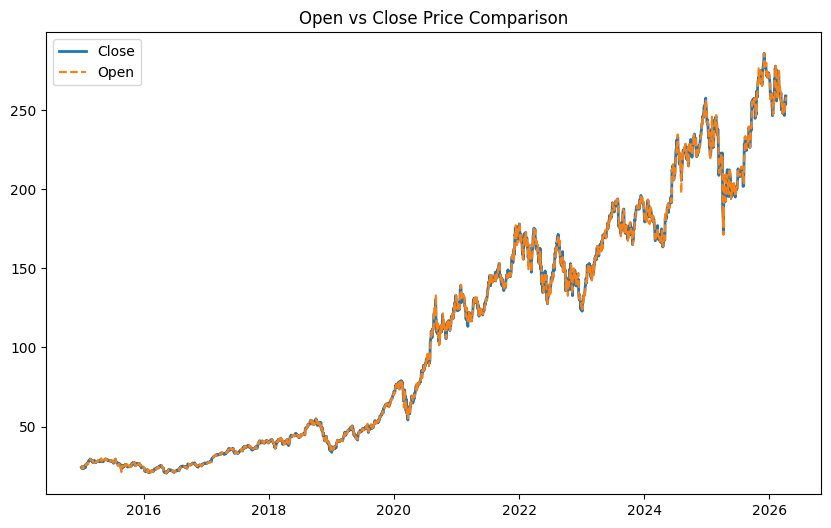

In [49]:
plt.figure(figsize=(10,6))

plt.plot(df.index, df["Close"], label="Close", linewidth=2)
plt.plot(df.index, df["Open"], label="Open", linestyle='--')

plt.legend()
plt.title("Open vs Close Price Comparison")
plt.show()

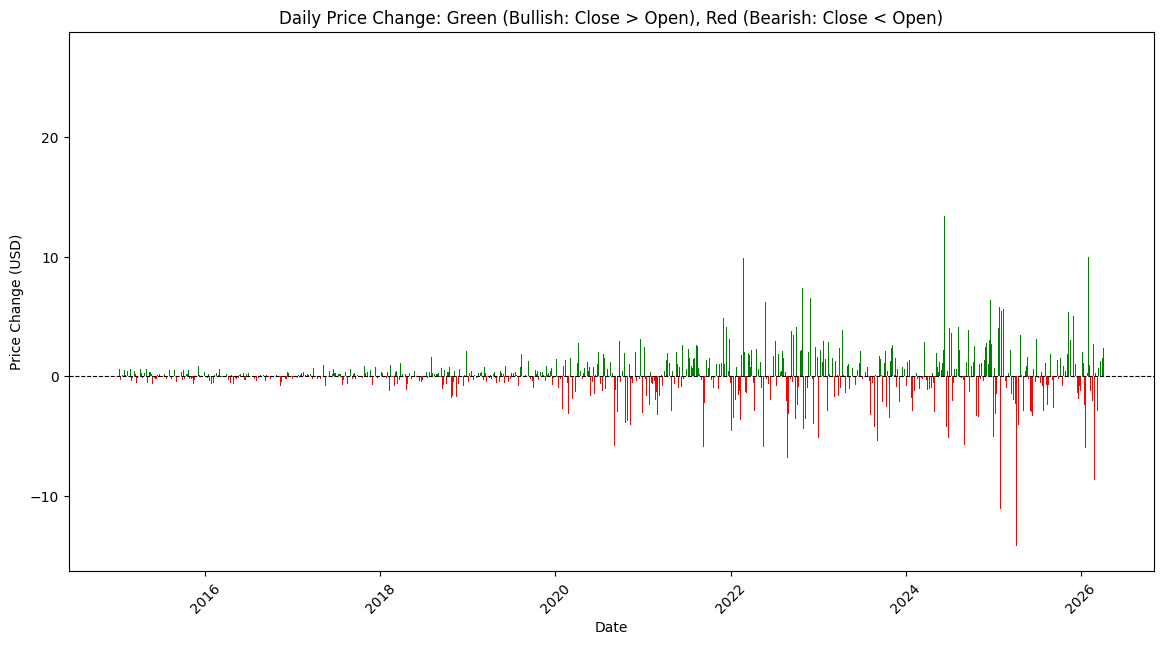

In [50]:
# Calculate the daily price difference
df['Diff'] = df['Close'] - df['Open']

# Assign colors: green for bullish (Diff > 0), red for bearish (Diff < 0)
colors = ['green' if x > 0 else 'red' for x in df['Diff']]

# Create the bar plot
plt.figure(figsize=(14, 7))  # Adjust figsize for better visibility with many data points
plt.bar(df.index, df['Diff'], color=colors, width=1)  # width=1 for daily bars; adjust if needed

# Add labels and title
plt.title('Daily Price Change: Green (Bullish: Close > Open), Red (Bearish: Close < Open)')
plt.xlabel('Date')
plt.ylabel('Price Change (USD)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')  # Horizontal line at zero for reference

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

plt.show()

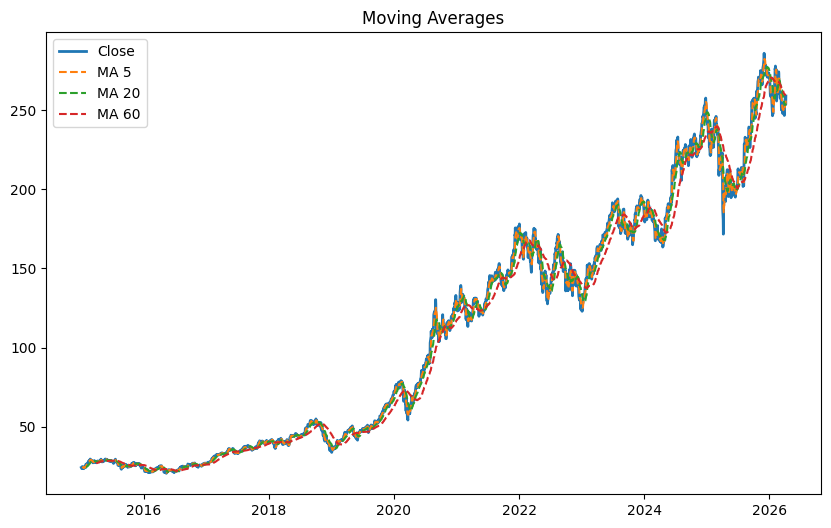

In [51]:
plt.figure(figsize=(10,6))
plt.plot(df.index, df["Close"], label="Close", linewidth=2)
plt.plot(df.index, df["MA_5"], label="MA 5", linestyle='--')
plt.plot(df.index, df["MA_20"], label="MA 20", linestyle='--')
plt.plot(df.index, df["MA_60"], label="MA 60", linestyle='--')
plt.legend()
plt.title("Moving Averages")
plt.show()

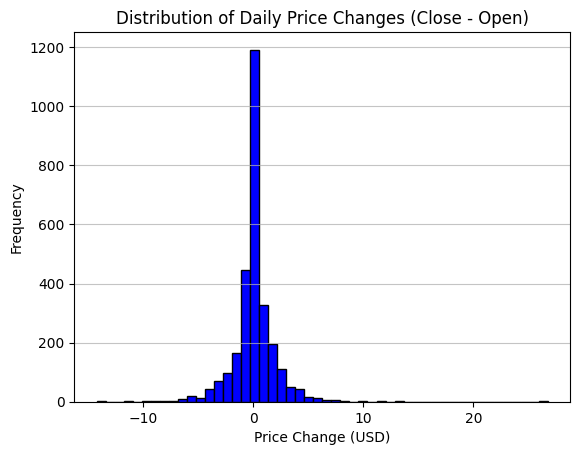

In [52]:
df['Diff'].plot(kind='hist', bins=50, color='blue', edgecolor='black')
plt.title('Distribution of Daily Price Changes (Close - Open)')
plt.xlabel('Price Change (USD)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

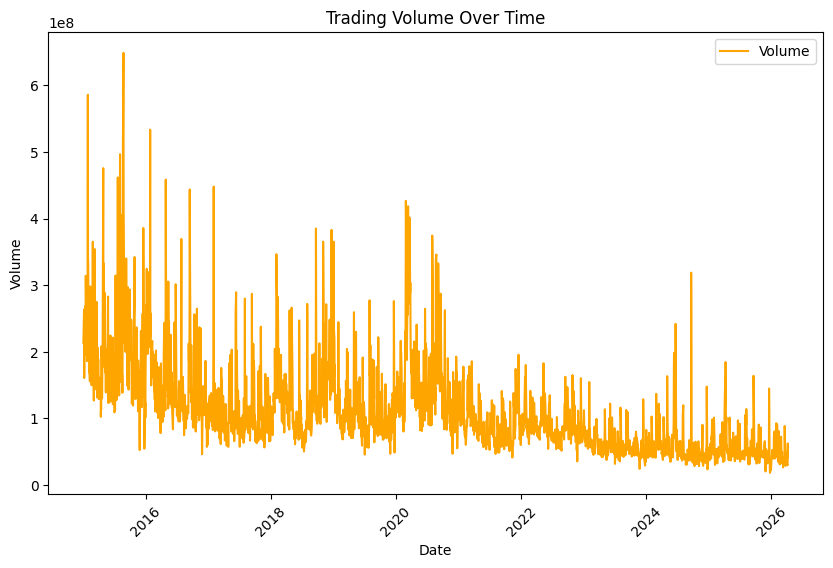

In [53]:
plt.figure(figsize=(10,6))
plt.plot(df.index,df["Volume"], label="Volume", color='orange')
plt.legend()
plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.xticks(rotation=45)
plt.show()  

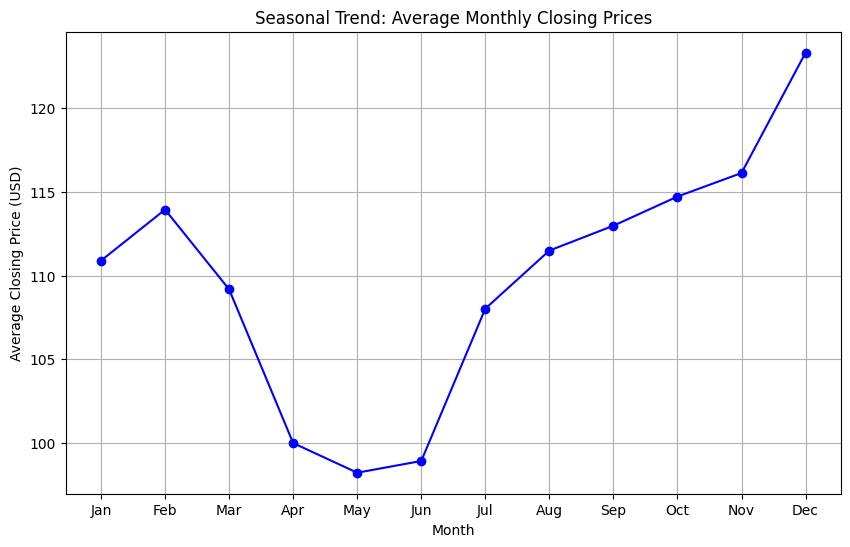

In [54]:
# Calculate monthly average closing prices
monthly_avg = df.groupby('Month')['Close'].mean()

# Plot the seasonal trend
plt.figure(figsize=(10, 6))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', linestyle='-', color='blue')
plt.title('Seasonal Trend: Average Monthly Closing Prices')
plt.xlabel('Month')
plt.ylabel('Average Closing Price (USD)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.show()

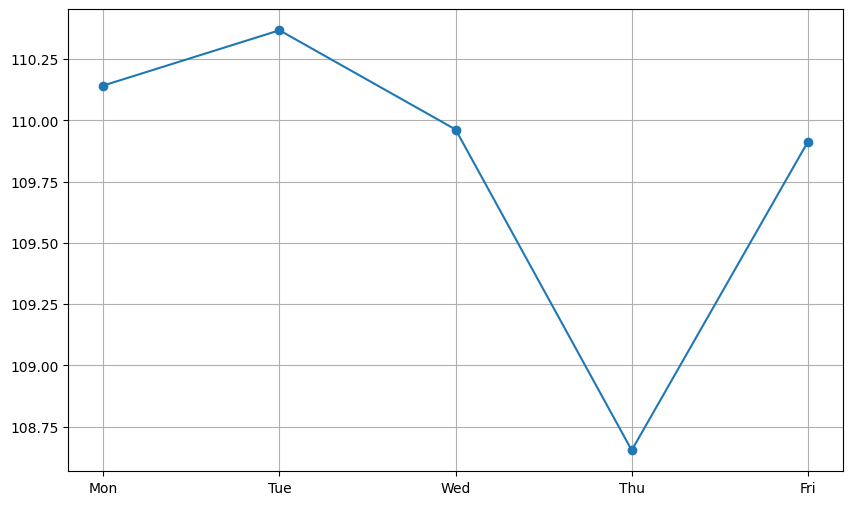

In [55]:
# Calculate monthly average closing prices
weekly_avg = df.groupby('DayOfWeek')['Close'].mean()

day_map = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']

plt.figure(figsize=(10, 6))
plt.plot(weekly_avg.index, weekly_avg.values, marker='o')

plt.xticks(weekly_avg.index, [day_map[i] for i in weekly_avg.index])
plt.grid(True)
plt.show()

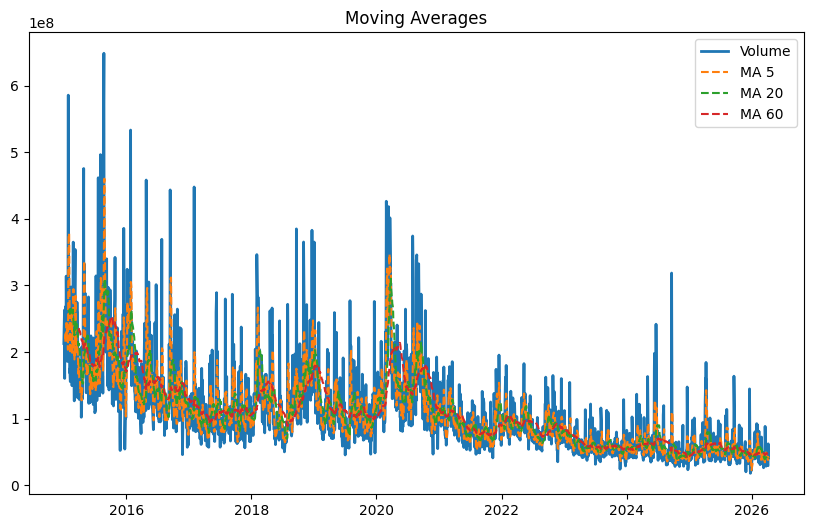

In [56]:
plt.figure(figsize=(10,6))
plt.plot(df.index, df["Volume"], label="Volume", linewidth=2)
plt.plot(df.index, df["Vol_5"], label="MA 5", linestyle='--')
plt.plot(df.index, df["Vol_20"], label="MA 20", linestyle='--')
plt.plot(df.index, df["Vol_60"], label="MA 60", linestyle='--')
plt.legend()
plt.title("Moving Averages")
plt.show()

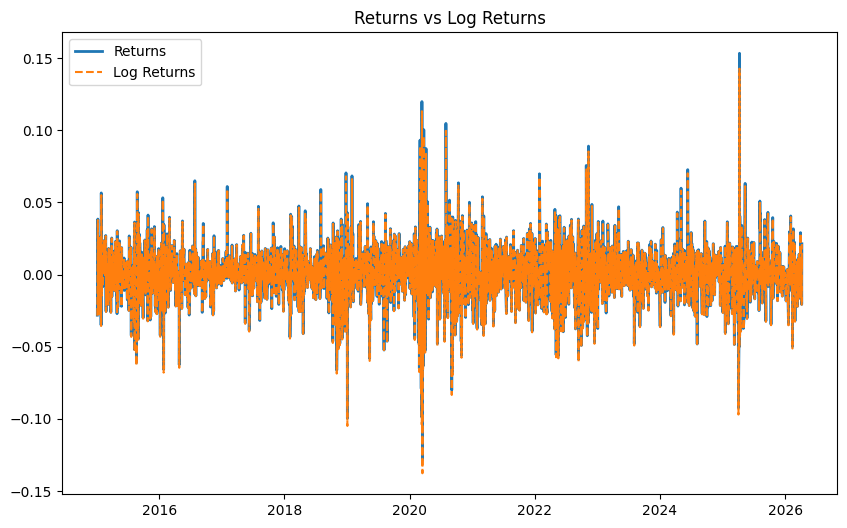

In [57]:
plt.figure(figsize=(10,6))
plt.plot(df.index, df["Returns"], label="Returns", linewidth=2)
plt.plot(df.index, df["Log_Returns"], label="Log Returns", linestyle='--')
plt.legend()
plt.title("Returns vs Log Returns")
plt.show()

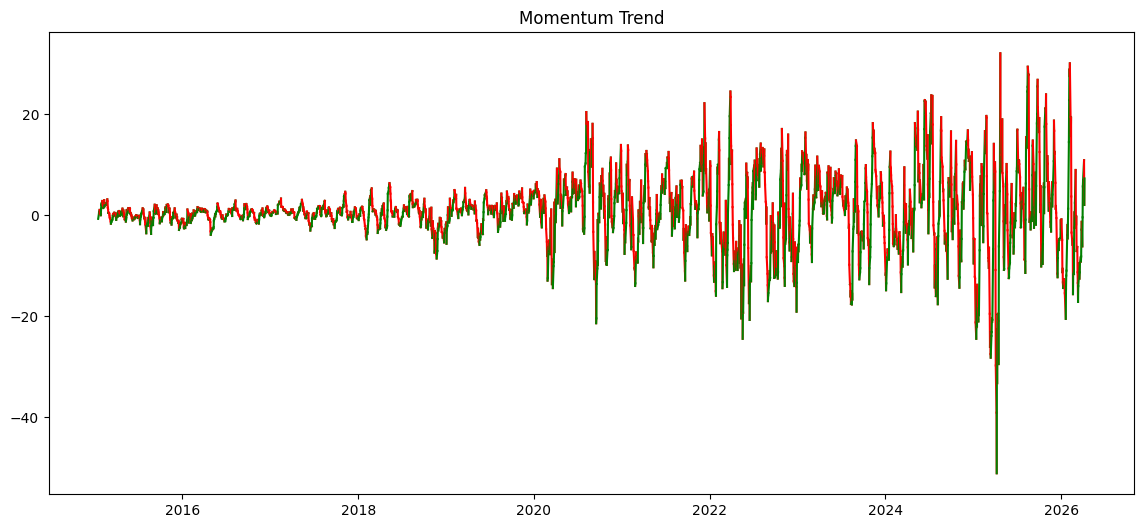

In [64]:
plt.figure(figsize=(14,6))

for i in range(1, len(df)):
    if df['Momentum'].iloc[i] > df['Momentum'].iloc[i-1]:
        plt.plot(df.index[i-1:i+1], df['Momentum'].iloc[i-1:i+1], color='green')
    else:
        plt.plot(df.index[i-1:i+1], df['Momentum'].iloc[i-1:i+1], color='red')

plt.title("Momentum Trend")
plt.show()

## Feature Selection

In [65]:
df.columns

MultiIndex([(          'Close', 'AAPL'),
            (           'High', 'AAPL'),
            (            'Low', 'AAPL'),
            (           'Open', 'AAPL'),
            (         'Volume', 'AAPL'),
            (           'MA_5',     ''),
            (          'MA_20',     ''),
            (          'MA_60',     ''),
            (          'Month',     ''),
            (           'Year',     ''),
            (      'Month_sin',     ''),
            (      'Month_cos',     ''),
            (      'DayOfWeek',     ''),
            (          'Vol_5',     ''),
            (         'Vol_20',     ''),
            (         'Vol_60',     ''),
            (        'Returns',     ''),
            (    'Log_Returns',     ''),
            (       'Momentum',     ''),
            (            'ROC',     ''),
            (     'Volatility',     ''),
            ('High_Low_Spread',     ''),
            ('Open_Close_Diff',     ''),
            ('High_Close_Diff',     ''),
            (   

In [66]:
df.columns = [col[0] for col in df.columns]

In [67]:
features = [
    'Close',
    'Returns',
    'Momentum',
    'Volatility',
    'Vol_20',
    'Vol_60',
    'MA_20',
    'MA_60',
    'High_Low_Spread',
    'Open_Close_Diff',
    'Volume',
    'Month_sin',
    'Month_cos',
    'DayOfWeek',
    'Momentum_prev',
    'ROC'
]

In [80]:
corr = df[features].corr()
corr


,Close,Returns,Momentum,Volatility,Vol_20,Vol_60,MA_20,MA_60,High_Low_Spread,Open_Close_Diff,Volume,Month_sin,Month_cos,DayOfWeek,Momentum_prev,ROC
Close,1.000000,0.005849,0.089732,-0.002684,-0.736501,-0.793230,0.997564,0.992825,0.713349,-0.042348,-0.583295,-0.033187,0.077114,-0.004003,0.087815,0.013132
Returns,0.005849,1.000000,0.252707,0.017980,-0.003277,0.004983,-0.014617,-0.014740,-0.026038,-0.636469,-0.047116,-0.015597,-0.025168,-0.048132,-0.035399,0.318522
Momentum,0.089732,0.252707,1.000000,-0.139578,-0.056214,-0.038791,0.026450,0.012865,-0.110950,-0.209280,-0.092883,-0.107701,-0.053748,-0.014501,0.888060,0.835412
Volatility,-0.002684,0.017980,-0.139578,1.000000,0.367410,0.214485,0.012150,0.032560,0.298016,-0.027783,0.346365,0.093984,0.017318,-0.008734,-0.172505,-0.185049
Vol_20,-0.736501,-0.003277,-0.056214,0.367410,1.000000,0.912910,-0.735030,-0.731813,-0.439386,0.027712,0.747463,0.059247,0.000193,0.000295,-0.060015,-0.053436
Vol_60,-0.793230,0.004983,-0.038791,0.214485,0.912910,1.000000,-0.793806,-0.790912,-0.503267,0.031525,0.674402,0.034742,-0.044222,-0.005160,-0.040689,-0.011148
MA_20,0.997564,-0.014617,0.026450,0.012150,-0.735030,-0.793806,1.000000,0.996834,0.724178,-0.022935,-0.577572,-0.018979,0.091946,-0.002278,0.029868,-0.039784
MA_60,0.992825,-0.014740,0.012865,0.032560,-0.731813,-0.790912,0.996834,1.000000,0.726652,-0.026076,-0.569347,0.021222,0.100093,-0.001365,0.013736,-0.045384
High_Low_Spread,0.713349,-0.026038,-0.110950,0.298016,-0.439386,-0.503267,0.724178,0.726652,1.000000,-0.036344,-0.211540,0.030284,0.059687,-0.001187,-0.105812,-0.135550
Open_Close_Diff,-0.042348,-0.636469,-0.209280,-0.027783,0.027712,0.031525,-0.022935,-0.026076,-0.036344,1.000000,0.026751,-0.000172,0.000920,0.050775,0.050460,-0.177363


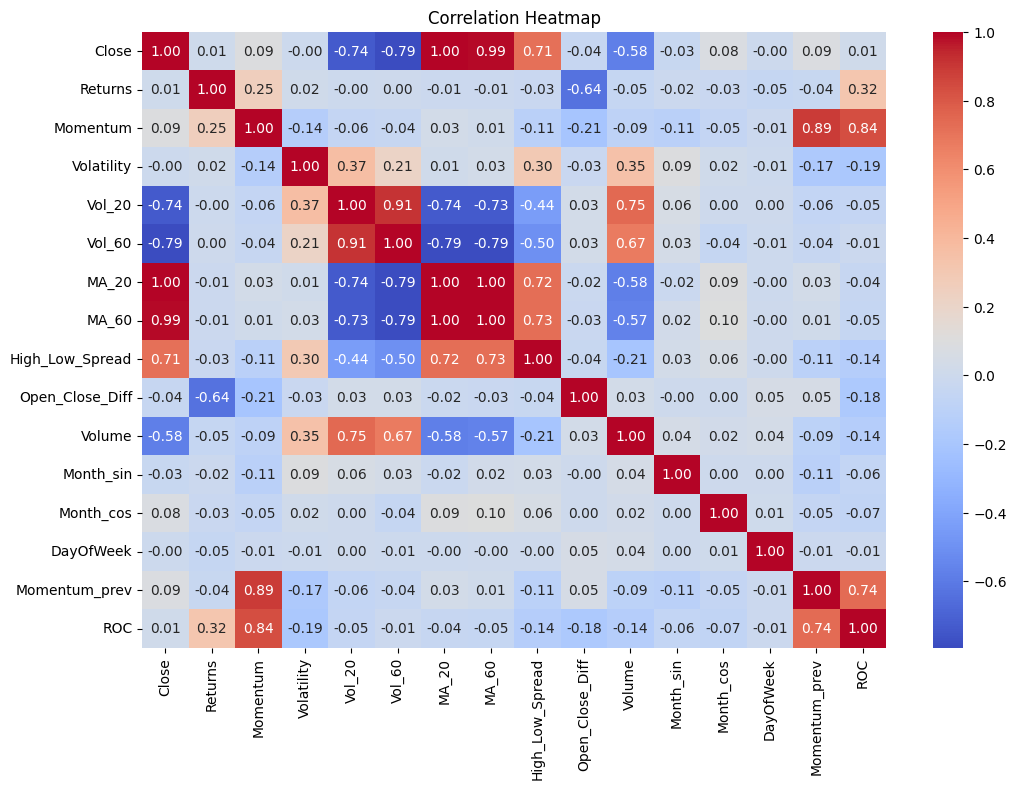

In [81]:
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [75]:
corr_matrix = df[features].corr().abs()

# Select upper triangle (to avoid duplicates)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation > 0.9
high_corr_features = [col for col in upper.columns if any(upper[col] > 0.9)]

print(high_corr_features)

['Vol_60', 'MA_20', 'MA_60']


In [83]:
df_clean = df[features].drop(columns=high_corr_features)
df_clean

,Close,Returns,Momentum,Volatility,Vol_20,High_Low_Spread,Open_Close_Diff,Volume,Month_sin,Month_cos,DayOfWeek,Momentum_prev,ROC
Date,,,,,,,,,,,,,
2015-01-02,24.214903,NaN,NaN,NaN,NaN,0.905873,0.456258,212818400,0.500000,0.866025,4,NaN,NaN
2015-01-05,23.532724,-0.028172,NaN,NaN,NaN,0.717609,0.451829,257142000,0.500000,0.866025,0,NaN,NaN
2015-01-06,23.534931,0.000094,NaN,NaN,NaN,0.620157,0.062015,263188400,0.500000,0.866025,1,NaN,NaN
2015-01-07,23.864948,0.014022,NaN,NaN,NaN,0.332227,-0.121817,160423600,0.500000,0.866025,2,NaN,NaN
2015-01-08,24.781895,0.038422,NaN,NaN,NaN,0.764122,-0.589148,237458000,0.500000,0.866025,3,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-01,255.630005,0.007250,5.690002,0.012585,40994760.0,2.849991,-1.550003,40059400,0.866025,-0.500000,2,-0.440002,0.022765
2026-04-02,255.919998,0.001134,6.959991,0.012406,40076300.0,5.480011,-1.720001,31289400,0.866025,-0.500000,3,5.690002,0.027956
2026-04-06,258.859985,0.011488,10.869980,0.012433,39486795.0,5.700012,-2.349976,29329900,0.866025,-0.500000,0,6.959991,0.043832


In [84]:
df_clean.dropna(inplace=True)

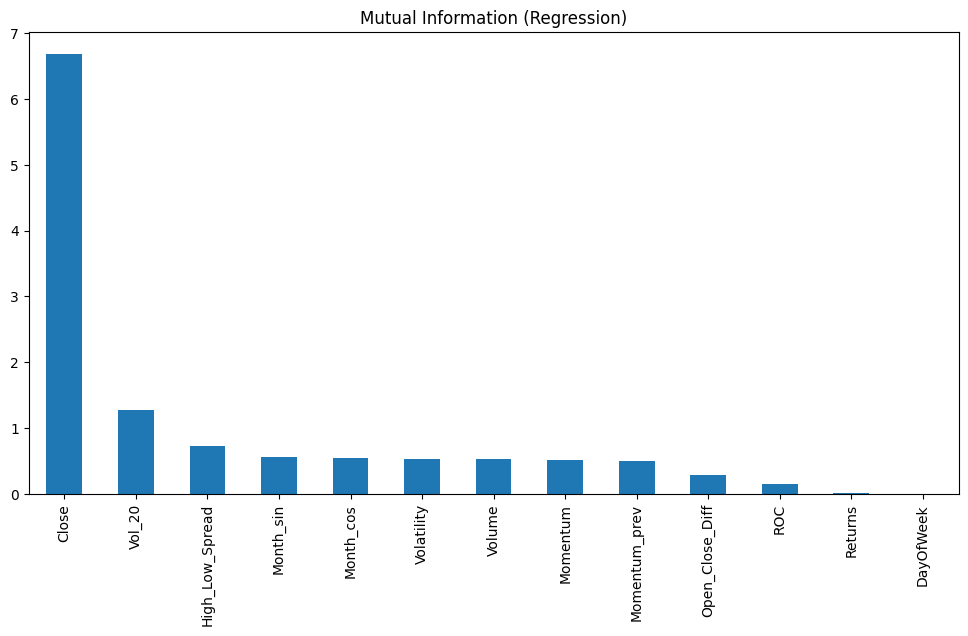

In [90]:
from sklearn.feature_selection import mutual_info_regression

mi = mutual_info_regression(df_clean, df_clean['Close'])

mi_scores = pd.Series(mi, index=df_clean.columns).sort_values(ascending=False)

mi_scores.plot(kind='bar', figsize=(12,6))
plt.title("Mutual Information (Regression)")
plt.show()

## Model Training

In [91]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [99]:
split = int(0.8 * len(df_clean))

X = df_clean.drop(columns=['Close'])
y = df_clean['Close']

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [100]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1,1))